# HLoc metric 6-DoF localization

This notebook builds a sparse reference map at the known ARKit camera poses, triangulates SuperPoint/LightGlue correspondences, and uses PnP to estimate every query camera pose in the **reference ARKit world frame**. AnyLoc provides the coarse query-to-reference retrieval pairs.

## One-time installation

Run `./scripts/install_hloc.sh` from the repository root, then restart this notebook kernel. HLoc and its pretrained feature weights download on first use. The adapter automatically isolates PyTorch and PyCOLMAP stages to avoid the macOS duplicate-OpenMP crash.

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src' / 'indoor_vpr').is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Could not find the indoor-VPR project root.')
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr.localization import HLocConfig, prepare_localization_frames, run_hloc

DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-3'
REFERENCE_RECORDING = DATASET_ROOT / 'SR_2026-08-30_01-46-38'
QUERY_RECORDING = DATASET_ROOT / 'SR_2026-08-30_01-48-04'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'localization'
IMAGE_ROOT = OUTPUT_DIR / 'images'
HLOC_ROOT = PROJECT_ROOT / 'third_party' / 'Hierarchical-Localization'

FRAME_STRIDE = 5
RETRIEVAL_TOP_K = 20
TEMPORAL_WINDOW = 5
LOCAL_FEATURES = 'superpoint_aachen'
MATCHER = 'superpoint+lightglue'
RANSAC_THRESHOLD_PX = 12.0

REFERENCE_MANIFEST, QUERY_MANIFEST = prepare_localization_frames(
    REFERENCE_RECORDING,
    QUERY_RECORDING,
    IMAGE_ROOT,
    frame_stride=FRAME_STRIDE,
)
ANYLOC_SIMILARITY_CSV = OUTPUT_DIR / 'anyloc_similarity.csv'
if not ANYLOC_SIMILARITY_CSV.is_file():
    raise FileNotFoundError(
        f'{ANYLOC_SIMILARITY_CSV} is missing. Run localization/anyloc.ipynb first.'
    )


## Run HLoc

Intermediate feature and match HDF5 files are reused on later runs. Set either overwrite option to `True` only when changing the corresponding model or input images.

In [4]:
config = HLocConfig(
    image_root=IMAGE_ROOT,
    reference_manifest=REFERENCE_MANIFEST,
    query_manifest=QUERY_MANIFEST,
    anyloc_similarity_csv=ANYLOC_SIMILARITY_CSV,
    output_dir=OUTPUT_DIR / 'hloc',
    hloc_root=HLOC_ROOT,
    retrieval_top_k=RETRIEVAL_TOP_K,
    temporal_window=TEMPORAL_WINDOW,
    local_feature_conf=LOCAL_FEATURES,
    matcher_conf=MATCHER,
    ransac_threshold_px=RANSAC_THRESHOLD_PX,
    overwrite_features=False,
    overwrite_matches=False,
)
artifacts = run_hloc(config)
for name, path in artifacts.items():
    print(f'{name:16s}: {path}')


[2026/08/30 13:55:53 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}
[2026/08/30 13:55:53 hloc.utils.parsers INFO] Imported 313 images from all-images.txt
[2026/08/30 13:55:53 hloc INFO] Skipping the extraction.
[2026/08/30 13:55:54 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2026/08/30 13:55:54 hloc INFO] Skipping the matching.
[2026/08/30 13:55:55 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2026/08/30 13:55:55 hloc INFO] Skipping the matching.
[2026/08/30 13:55:55 hloc WARNING] The database already exists, deleting it.
[2026/08/30 13:55:55 hloc INFO] Importing features into the 

reference_pairs : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/pairs-reference-temporal.txt
query_pairs     : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/pairs-query-anyloc.txt
query_list      : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/queries-with-intrinsics.txt
features        : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/feats-superpoint-n4096-r1024.h5
matches         : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/matches-superpoint-lightglue.h5
reference_sfm   : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/reference_sfm
poses_txt       : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/hloc_poses.txt
poses_xlsx      : /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/hloc_poses.xlsx


## Result

`hloc_poses.xlsx` contains `T_reference_world_camera` for each query. A failed PnP query is marked explicitly; HLoc's nearest-reference fallback is not counted as a successful 6-DoF estimate by the benchmark.

In [5]:
print('Pose text: ', OUTPUT_DIR / 'hloc' / 'hloc_poses.txt')
print('Pose Excel:', OUTPUT_DIR / 'hloc' / 'hloc_poses.xlsx')
print('Next: run benchmark_hloc.ipynb; it does not rerun HLoc.')


Pose text:  /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/hloc_poses.txt
Pose Excel: /Users/armin/Documents/indoor-VPR/outputs/localization/hloc/hloc_poses.xlsx
Next: run benchmark_hloc.ipynb; it does not rerun HLoc.


## Inspect local correspondences

This section is independent of the localization run. Change `QUERY_IMAGE` to inspect how LightGlue connected one query to its AnyLoc-retrieved references. Line colors represent relative matching confidence.

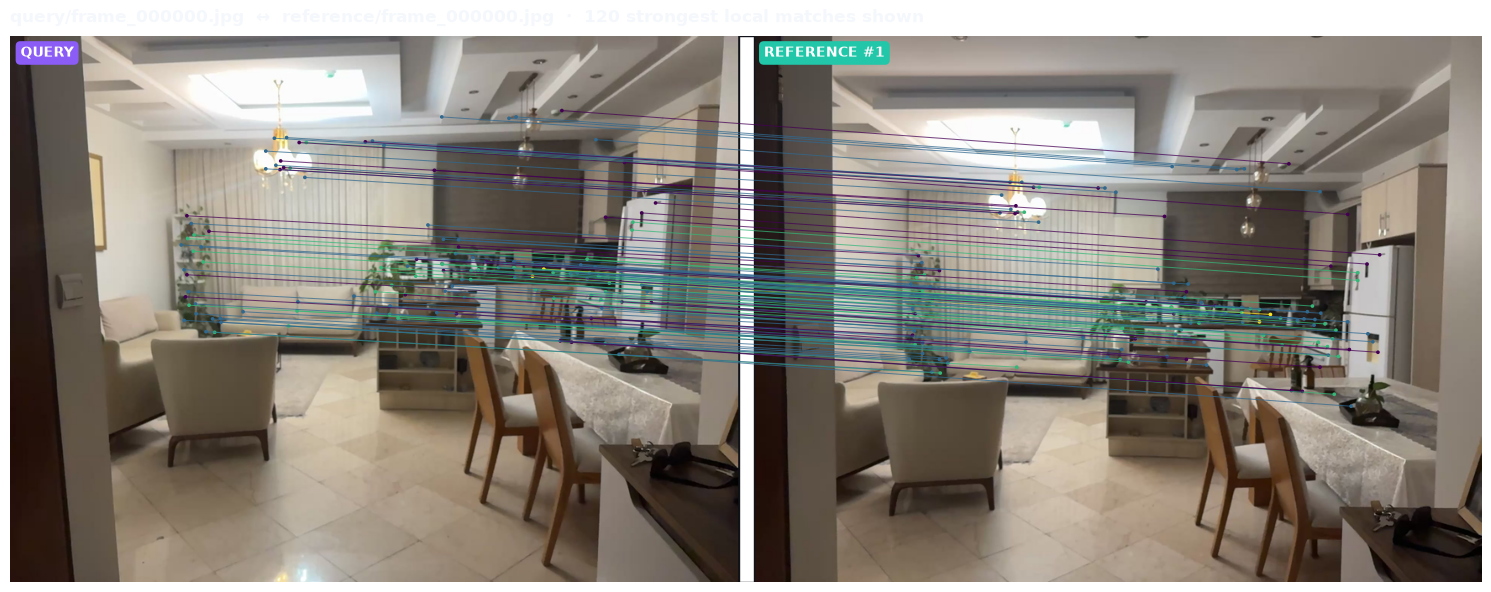

/Users/armin/Documents/indoor-VPR/outputs/localization/hloc_correspondences_frame_000000_rank1.png


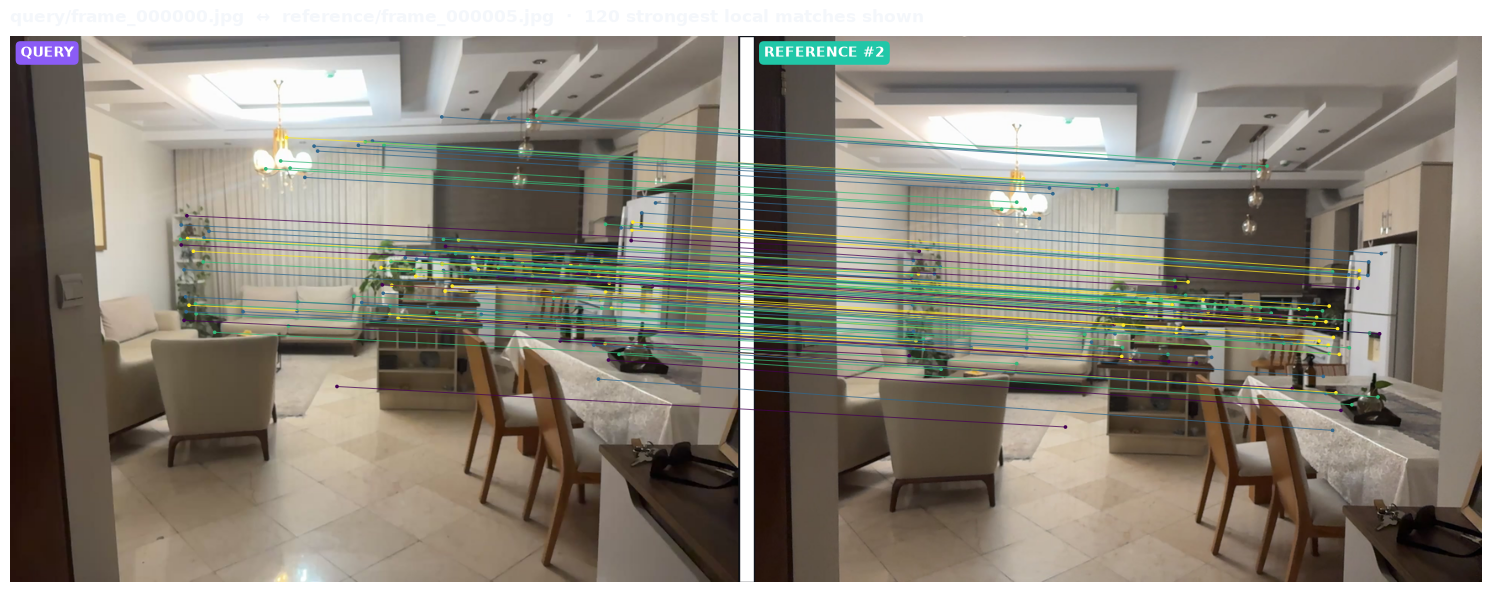

/Users/armin/Documents/indoor-VPR/outputs/localization/hloc_correspondences_frame_000000_rank2.png


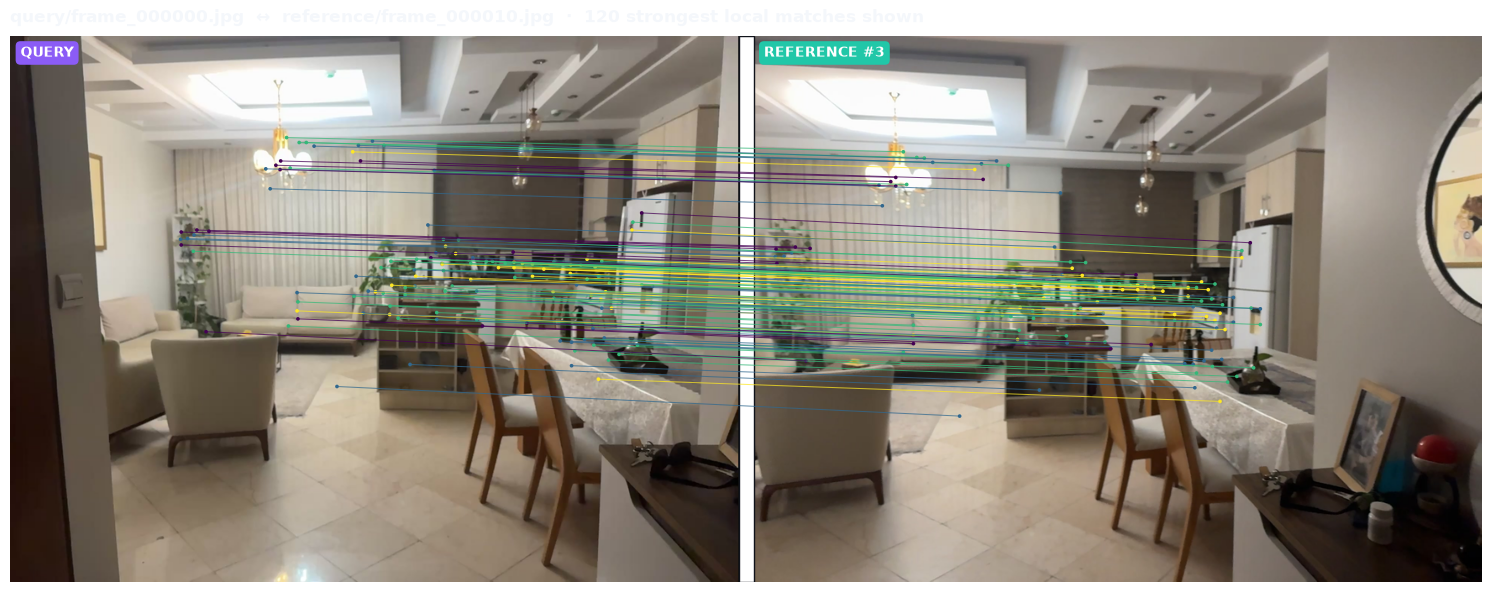

/Users/armin/Documents/indoor-VPR/outputs/localization/hloc_correspondences_frame_000000_rank3.png


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src' / 'indoor_vpr').is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Could not find the indoor-VPR project root.')
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
from IPython.display import display
from indoor_vpr.localization import show_hloc_correspondences

def apply_light_theme(figure):
    """Restyle local-correspondence figures for a white thesis page."""
    figure.set_facecolor('white')
    for axis in figure.axes:
        axis.set_facecolor('white')
        axis.title.set_color('#172033')
        # The original dark separator is an axvspan patch, so recolour it too.
        for patch in axis.patches:
            patch.set_facecolor('white')
            patch.set_alpha(1)

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'localization'
HLOC_DIR = OUTPUT_DIR / 'hloc'
QUERY_IMAGE = 'frame_000000.jpg'
NUMBER_OF_REFERENCES = 3
MAX_MATCHES_PER_REFERENCE = 120

figures = show_hloc_correspondences(
    QUERY_IMAGE,
    OUTPUT_DIR / 'images',
    HLOC_DIR / 'pairs-query-anyloc.txt',
    HLOC_DIR / 'feats-superpoint-n4096-r1024.h5',
    HLOC_DIR / 'matches-superpoint-lightglue.h5',
    max_reference_images=NUMBER_OF_REFERENCES,
    max_matches=MAX_MATCHES_PER_REFERENCE,
)
for rank, figure in enumerate(figures, start=1):
    apply_light_theme(figure)
    path = OUTPUT_DIR / f'hloc_correspondences_{Path(QUERY_IMAGE).stem}_rank{rank}.png'
    figure.savefig(path, dpi=140, facecolor=figure.get_facecolor())
    display(figure)
    plt.close(figure)
    print(path)
